In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


### Opdracht 1 K-means clusering

We gaan k-means clustering implementeren zonder externe libraries

Stel er zijn volgende tuples gegeven.
(1,1), (2,1), (4,5), (5,4)

Maak er een lijst van.

Kies 2 punten (tuples) waar we beginnen (Hoeft niet een van die punten te zijn). Welke datastructuur ga je gebruiken?

In [3]:
tuples = [(1,1), (2,1), (4,5), (5,4), (1,0), (0,1), (5,5), (6,5)]
points = [(3,2), (1,2)]

Maak een functie die de afstand bepaalt tussen 2 punten.

    def dist(a, b):
        ...
        return afstand

In [4]:
def dist(a,b):
    # a^2 + b^2 = c^2
    return np.sqrt(abs(a[0] - b[0])**2 + abs(a[1] - b[1])**2)

In de eerste stap gaan we door alle punten en voegen ze toe aan 2 clusters. Gebruik je **dist** functie en de 2 startpunten om te bepalen in welke cluster de punten terechtkomen. 

Gebruik een datastructuur naar keuze. 

Welke is handig hier? Waarom?

- Ik heb voor een dictionary gekozen omdat ik makkelijk de centroid als key kan gebruiken en de punten als values in een lijst kan opslaan.

In [5]:
def add_points_to_clusters(points, tuples):
    clusters = {}
    for cluster_tuple in tuples:
        closest_point = None
        closest_distance = float('inf')
        for point in points:
            distance = dist(cluster_tuple, point)
            if distance < closest_distance:
                closest_distance = distance
                closest_point = point
        
        if closest_point not in clusters:
            clusters[closest_point] = []
        clusters[closest_point].append(cluster_tuple)
    return clusters

Aan de hand van de gevonden clusters bereken nieuwe centroids

In [6]:
def calculate_new_centroids(clusters):
    new_centroids = {}
    for _, points in clusters.items():
        x_coords = [point[0] for point in points]
        y_coords = [point[1] for point in points]
        new_centroid = (sum(x_coords) / len(points), sum(y_coords) / len(points))
        new_centroids[new_centroid] = points
    return new_centroids

Herhaal de voorgaande stappen indien nodig.

In [7]:
clusters = None

for i in range(10):
    clusters = add_points_to_clusters(points, tuples)
    points = calculate_new_centroids(clusters).keys()

print(clusters)

{(1.0, 0.75): [(1, 1), (2, 1), (1, 0), (0, 1)], (5.0, 4.75): [(4, 5), (5, 4), (5, 5), (6, 5)]}



Probeer je code te runnen met veel meer punten. Wat kun je hier over zeggen?

- De centroids komen steeds dichter bij de clusters te liggen naarmate je meer iteraties doet.

### Opdracht 2: Experimenteren met PCA

In deze opdracht ga je kennismaken met Principal Component Analysis (PCA) door een bekende dataset te gebruiken: de Iris dataset. Je onderzoekt eerst hoe de data eruitziet, voert vervolgens PCA uit en bekijkt wat er verandert.

### Laad de Iris dataset
Gebruik de functie 

    load_iris()

uit scikit-learn om de dataset binnen te halen.
De Iris dataset bevat twee belangrijke onderdelen:

    .data

Dit is een matrix (2D array) met alle numerieke kenmerken van de bloemen.
Elke rij is een bloem, elke kolom is een feature (bijv. kelkblad-lengte, kelkblad-breedte, etc.).


    .target
    
Dit is een vector (1D array) met labels: welke soort Iris-bloem het is voor elke rij in .data.


Leg kort uit wat deze twee onderdelen voorstellen.

- De data is een 4 dimensionale dataset van bloemen. elke kolom is een kenmerk van een bloem.

- Target is een indicator van welke soort bloem het is.

In [8]:
item = load_iris()

### Bekijk de ruwe data

Print de eerste 5 rijen van .data.
Dit geeft je een beeld van de oorspronkelijke kenmerken vóór de PCA.

In [9]:
for i in range(5):
    print("bloem data:", item.data[i], "target:", item.target[i])


bloem data: [5.1 3.5 1.4 0.2] target: 0
bloem data: [4.9 3.  1.4 0.2] target: 0
bloem data: [4.7 3.2 1.3 0.2] target: 0
bloem data: [4.6 3.1 1.5 0.2] target: 0
bloem data: [5.  3.6 1.4 0.2] target: 0


### Pas PCA toe

- Maak een PCA-model met:

        PCA(n_components=2)


- Transformeer de dataset, zodat je nieuwe data krijgt met slechts 2 hoofcomponenten.


- Print opnieuw de eerste 5 rijen, maar nu van de getransformeerde data (dus na PCA).




In [10]:
pcamodel = PCA(n_components=2)
pcamodel.fit(item.data)

transformed_data = pcamodel.transform(item.data)

for i in range(5):
    print(f"Bloem {i}: {transformed_data[i]}, target: {item.target[i]}")

Bloem 0: [-2.68412563  0.31939725], target: 0
Bloem 1: [-2.71414169 -0.17700123], target: 0
Bloem 2: [-2.88899057 -0.14494943], target: 0
Bloem 3: [-2.74534286 -0.31829898], target: 0
Bloem 4: [-2.72871654  0.32675451], target: 0


### Visualisatie

Maak een scatterplot met de twee PCA-componenten.
Geef eventueel verschillende kleuren voor de drie Iris‑soorten.

Text(0.5, 1.0, 'PCA of Iris Dataset')

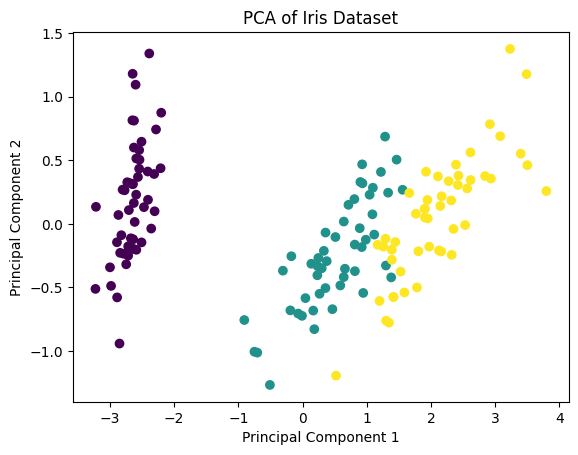

In [12]:
plt.scatter(transformed_data[:,0], transformed_data[:,1], c=item.target)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')

### Inleveren

Lever in op CodeGrade onder **2.2 Unsupervised Learning**